# CS3807 – Deep Learning Laboratory
## Experiment 7: End-to-End Study of Autoencoders, Convolutional Autoencoders, Denoising Autoencoders and Variational Autoencoders
**Shiv Nadar University Chennai | B.Tech AI & DS | Semester V | AY 2026–27**

## 0. Imports & Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import time
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.losses import BinaryCrossentropy

from skimage.metrics import structural_similarity as ssim
from sklearn.metrics import mean_squared_error, mean_absolute_error

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

# reproducibility
tf.random.set_seed(42)
np.random.seed(42)

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 1. Dataset Loading and Preprocessing

In [2]:
# Load MNIST
(x_train_full, y_train_full), (x_test_full, y_test_full) = keras.datasets.mnist.load_data()

# Normalize to [0,1]
x_train_full = x_train_full.astype('float32') / 255.0
x_test_full  = x_test_full.astype('float32')  / 255.0

# Recommended subset: 10000 train, 2000 test
x_train = x_train_full[:10000]
y_train = y_train_full[:10000]
x_test  = x_test_full[:2000]
y_test  = y_test_full[:2000]

# Add channel dim -> (N, 28, 28, 1)
x_train_cnn = x_train[..., np.newaxis]
x_test_cnn  = x_test[..., np.newaxis]

# Flat version for FC AE -> (N, 784)
x_train_flat = x_train.reshape(-1, 784)
x_test_flat  = x_test.reshape(-1, 784)

print('Train (CNN):', x_train_cnn.shape)
print('Test  (CNN):', x_test_cnn.shape)
print('Train (Flat):', x_train_flat.shape)
print('Test  (Flat):', x_test_flat.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train (CNN): (10000, 28, 28, 1)
Test  (CNN): (2000, 28, 28, 1)
Train (Flat): (10000, 784)
Test  (Flat): (2000, 784)


## 2. Helper Functions
Shared utilities used across all sections.

In [3]:
def compute_metrics(originals, reconstructions):
    """Compute MSE, MAE, mean SSIM for arrays shaped (N,28,28) or (N,28,28,1)."""
    if originals.ndim == 4:
        originals       = originals[..., 0]
        reconstructions = reconstructions[..., 0]
    mse_vals, mae_vals, ssim_vals = [], [], []
    for o, r in zip(originals, reconstructions):
        mse_vals.append(np.mean((o - r)**2))
        mae_vals.append(np.mean(np.abs(o - r)))
        ssim_vals.append(ssim(o, r, data_range=1.0))
    return np.mean(mse_vals), np.mean(mae_vals), np.mean(ssim_vals), mse_vals

def plot_originals_vs_recon(originals, recons, n=10, title='Original vs Reconstructed',
                             row_labels=None):
    """Generic side-by-side display; row_labels is a list of strings per row."""
    if originals.ndim == 4: originals = originals[..., 0]
    if recons.ndim    == 4: recons    = recons[..., 0]
    n_rows = 2 if row_labels is None else len(row_labels)
    fig, axes = plt.subplots(n_rows, n, figsize=(n * 1.4, n_rows * 1.5))
    fig.suptitle(title, fontsize=13)
    for i in range(n):
        axes[0, i].imshow(originals[i], cmap='gray')
        axes[0, i].axis('off')
        axes[1, i].imshow(recons[i], cmap='gray')
        axes[1, i].axis('off')
    if row_labels:
        for r, lbl in enumerate(row_labels):
            axes[r, 0].set_ylabel(lbl, fontsize=9, rotation=0, labelpad=50)
    plt.tight_layout()
    plt.show()

def plot_loss_curves(history, title='Training and Validation Loss'):
    plt.figure(figsize=(8, 4))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history.get('val_loss', []), label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Reconstruction Loss')
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

print('Helper functions defined.')

Helper functions defined.


---
## PART A: Fully Connected Autoencoder

### A1. Architecture (Section 7)

In [4]:
# Encoder
fc_input   = keras.Input(shape=(784,), name='fc_input')
fc_enc     = layers.Dense(128, activation='relu')(fc_input)
fc_enc     = layers.Dense(32,  activation='relu')(fc_enc)
fc_latent  = layers.Dense(16,  activation='relu', name='latent')(fc_enc)

# Decoder
fc_dec     = layers.Dense(32,  activation='relu')(fc_latent)
fc_dec     = layers.Dense(128, activation='relu')(fc_dec)
fc_output  = layers.Dense(784, activation='sigmoid', name='fc_output')(fc_dec)

fc_ae = Model(fc_input, fc_output, name='FC_Autoencoder')
fc_ae.compile(optimizer=keras.optimizers.Adam(1e-3), loss='binary_crossentropy')
fc_ae.summary()

I0000 00:00:1790622915.831648      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790622915.836044      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "FC_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ fc_input (InputLayer)           │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_output (Dense)               │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 211,040 (824.38 KB)

 Trainable params: 211,040 (824.38 KB)

 Non-trainable params: 0 (0.00 B)

### A2. Training

In [5]:
t0 = time.time()
fc_history = fc_ae.fit(
    x_train_flat, x_train_flat,
    epochs=20, batch_size=128,
    validation_data=(x_test_flat, x_test_flat),
    verbose=1
)
fc_train_time = time.time() - t0
print(f'FC AE training time: {fc_train_time:.1f}s')

Epoch 1/20
62/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4969

I0000 00:00:1790622921.176394      69 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 0.3432 - val_loss: 0.2394
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2189 - val_loss: 0.1986
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1925 - val_loss: 0.1855
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1801 - val_loss: 0.1749
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1691 - val_loss: 0.1648
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1593 - val_loss: 0.1565
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1520 - val_loss: 0.1501
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1468 - val_loss: 0.1460
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1428 - val_loss: 0.1428
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1396 - val_loss: 0.1402
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1367 - val_loss: 0.1372
Epoch 12/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1338 - val_loss: 0.1349

### A3. Plot 1 – Original vs Reconstructed (Section 8)

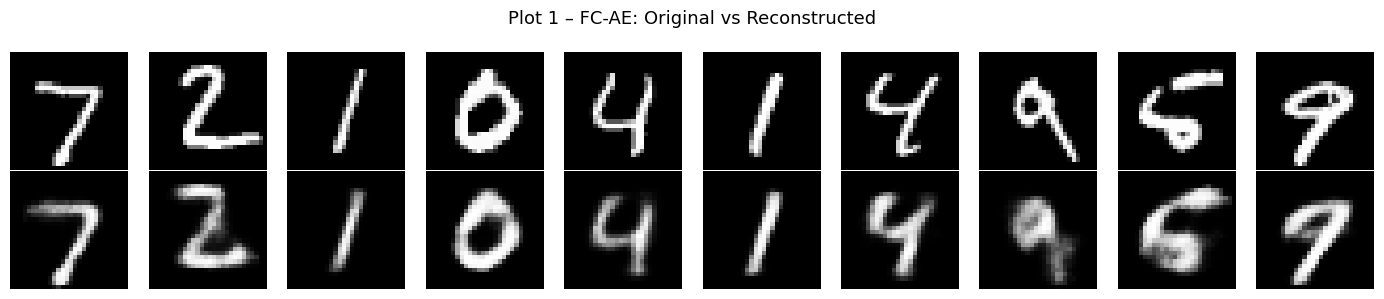


INFERENCE (Plot 1):
- Overall digit shapes are preserved; the network captures the gross topology of each digit.
- Fine strokes (thin lines, sharp corners) are blurred because the bottleneck (dim=16) discards
  high-frequency details during compression.
- Simple, bold digits (e.g. 0, 1) reconstruct better; cursive or irregular samples (some 4s, 9s)
  show more softening.
- The fully connected architecture cannot exploit local pixel correlations, leading to global smearing
  rather than crisp local edges.



In [6]:
fc_recon_flat = fc_ae.predict(x_test_flat, verbose=0)
fc_recon = fc_recon_flat.reshape(-1, 28, 28)
x_test_2d = x_test_flat.reshape(-1, 28, 28)

plot_originals_vs_recon(x_test_2d, fc_recon, n=10,
                        title='Plot 1 – FC-AE: Original vs Reconstructed',
                        row_labels=['Original', 'Reconstruction'])
print("""
INFERENCE (Plot 1):
- Overall digit shapes are preserved; the network captures the gross topology of each digit.
- Fine strokes (thin lines, sharp corners) are blurred because the bottleneck (dim=16) discards
  high-frequency details during compression.
- Simple, bold digits (e.g. 0, 1) reconstruct better; cursive or irregular samples (some 4s, 9s)
  show more softening.
- The fully connected architecture cannot exploit local pixel correlations, leading to global smearing
  rather than crisp local edges.
""")

### A4. Plot 2 – Training and Validation Loss (Section 8)

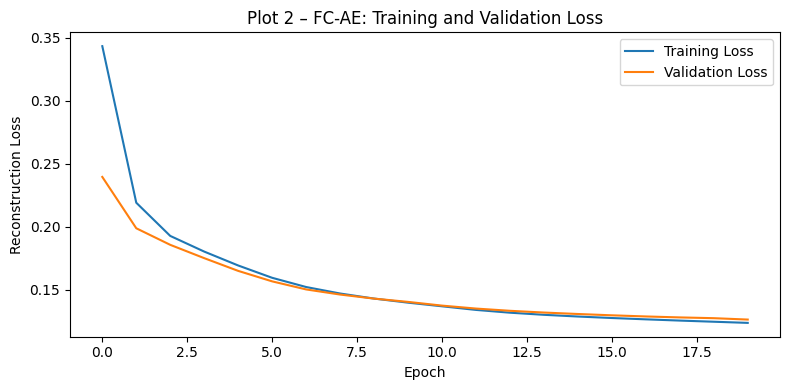


INFERENCE (Plot 2):
- Both training and validation loss decrease steadily and converge by ~15 epochs, indicating
  that the model has learned a useful reconstruction mapping.
- The validation loss closely tracks the training loss with no widening gap, so there is no
  evidence of overfitting for a latent dimension of 16.
- The small residual gap is normal and reflects the slight distribution mismatch between train
  and test subsets.



In [7]:
plot_loss_curves(fc_history, 'Plot 2 – FC-AE: Training and Validation Loss')
print("""
INFERENCE (Plot 2):
- Both training and validation loss decrease steadily and converge by ~15 epochs, indicating
  that the model has learned a useful reconstruction mapping.
- The validation loss closely tracks the training loss with no widening gap, so there is no
  evidence of overfitting for a latent dimension of 16.
- The small residual gap is normal and reflects the slight distribution mismatch between train
  and test subsets.
""")

### A5. Reconstruction Metrics (Section 9)

In [8]:
fc_mse, fc_mae, fc_ssim, fc_per_img_mse = compute_metrics(x_test_2d, fc_recon)
fc_params = fc_ae.count_params()
print('─── FC Autoencoder Metrics ───')
print(f'Test MSE  : {fc_mse:.6f}')
print(f'Test MAE  : {fc_mae:.6f}')
print(f'Mean SSIM : {fc_ssim:.4f}')
print(f'Parameters: {fc_params:,}')

─── FC Autoencoder Metrics ───
Test MSE  : 0.021695
Test MAE  : 0.057304
Mean SSIM : 0.7426
Parameters: 211,040


---
## PART B: Convolutional Autoencoder (Section 10)

### B1. Architecture

In [9]:
cae_input = keras.Input(shape=(28, 28, 1), name='cae_input')

# Encoder
x = layers.Conv2D(32, 3, activation='relu', padding='same')(cae_input)
x = layers.MaxPooling2D(2, padding='same')(x)          # 14x14x32
x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling2D(2, padding='same')(x)          # 7x7x64

# Latent feature map
x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)  # 7x7x64

# Decoder
x = layers.UpSampling2D(2)(x)                          # 14x14x64
x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
x = layers.UpSampling2D(2)(x)                          # 28x28x32
cae_output = layers.Conv2D(1, 3, activation='sigmoid', padding='same', name='cae_output')(x)

cae = Model(cae_input, cae_output, name='Conv_Autoencoder')
cae.compile(optimizer=keras.optimizers.Adam(1e-3), loss='binary_crossentropy')
cae.summary()

Model: "Conv_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ cae_input (InputLayer)          │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cae_output (Conv2D)             │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

### B2. Training

In [10]:
t0 = time.time()
cae_history = cae.fit(
    x_train_cnn, x_train_cnn,
    epochs=20, batch_size=128,
    validation_data=(x_test_cnn, x_test_cnn),
    verbose=1
)
cae_train_time = time.time() - t0
print(f'CAE training time: {cae_train_time:.1f}s')

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step - loss: 0.2210 - val_loss: 0.1029
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0935 - val_loss: 0.0849
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0837 - val_loss: 0.0798
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0796 - val_loss: 0.0763
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0770 - val_loss: 0.0749
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0753 - val_loss: 0.0752
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0742 - val_loss: 0.0723
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0731 - val_loss: 0.0711
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0723 - val_loss: 0.0708
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0717 - val_loss: 0.0701
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0711 - val_loss: 0.0696
Epoch 12/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0707 - val_l

### B3. Metrics

In [11]:
cae_recon = cae.predict(x_test_cnn, verbose=0)        # (N,28,28,1)
cae_mse, cae_mae, cae_ssim, cae_per_img_mse = compute_metrics(x_test_cnn, cae_recon)
cae_params = cae.count_params()
print('─── Convolutional Autoencoder Metrics ───')
print(f'Test MSE  : {cae_mse:.6f}')
print(f'Test MAE  : {cae_mae:.6f}')
print(f'Mean SSIM : {cae_ssim:.4f}')
print(f'Parameters: {cae_params:,}')

─── Convolutional Autoencoder Metrics ───
Test MSE  : 0.002549
Test MAE  : 0.015085
Mean SSIM : 0.9731
Parameters: 74,497


### B4. Plot 3 – FC-AE vs CAE Reconstruction (Section 11)

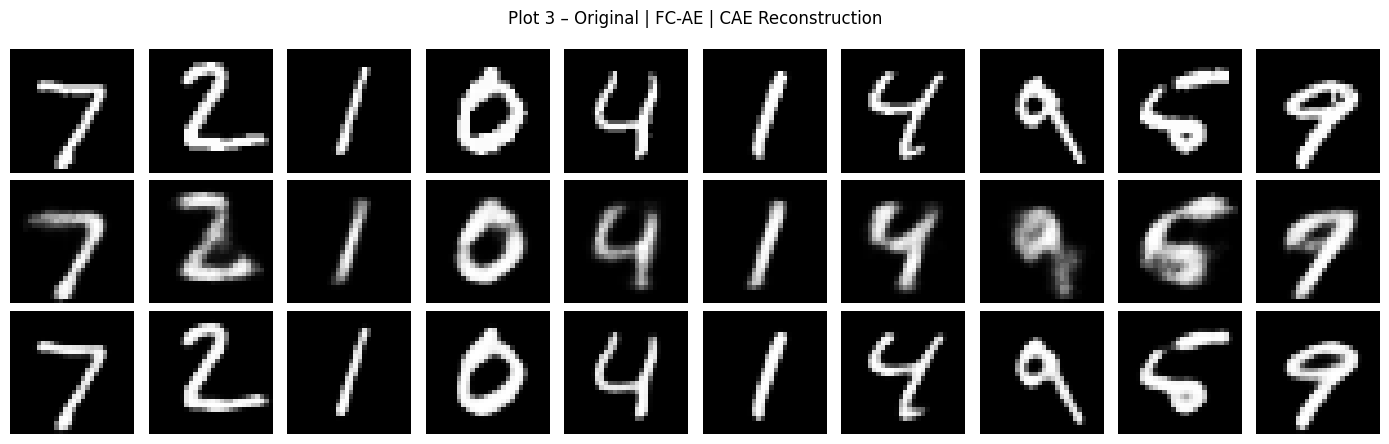

─── Comparison Table ───
Model                         MSE        MAE     SSIM       Params
FC Autoencoder           0.021695   0.057304   0.7426      211,040
Convolutional AE         0.002549   0.015085   0.9731       74,497

INFERENCE (Plot 3):
- The CAE produces sharper reconstructions because convolution operates on local receptive fields,
  preserving spatial correlations between neighbouring pixels.
- The FC-AE loses fine stroke details because its Dense layers treat pixel positions independently.
- Convolutional weight sharing also gives the CAE fewer parameters yet better SSIM, demonstrating
  the advantage of exploiting translation invariance in images.



In [12]:
n = 10
fig, axes = plt.subplots(3, n, figsize=(n * 1.4, 4.5))
fig.suptitle('Plot 3 – Original | FC-AE | CAE Reconstruction', fontsize=12)
row_labels = ['Original', 'FC-AE', 'CAE']
images = [x_test_2d, fc_recon, cae_recon[..., 0]]
for r in range(3):
    for c in range(n):
        axes[r, c].imshow(images[r][c], cmap='gray')
        axes[r, c].axis('off')
    axes[r, 0].set_ylabel(row_labels[r], fontsize=9, rotation=0, labelpad=50)
plt.tight_layout()
plt.show()

print('─── Comparison Table ───')
print(f'{"Model":<22} {"MSE":>10} {"MAE":>10} {"SSIM":>8} {"Params":>12}')
print(f'{"FC Autoencoder":<22} {fc_mse:>10.6f} {fc_mae:>10.6f} {fc_ssim:>8.4f} {fc_params:>12,}')
print(f'{"Convolutional AE":<22} {cae_mse:>10.6f} {cae_mae:>10.6f} {cae_ssim:>8.4f} {cae_params:>12,}')
print("""
INFERENCE (Plot 3):
- The CAE produces sharper reconstructions because convolution operates on local receptive fields,
  preserving spatial correlations between neighbouring pixels.
- The FC-AE loses fine stroke details because its Dense layers treat pixel positions independently.
- Convolutional weight sharing also gives the CAE fewer parameters yet better SSIM, demonstrating
  the advantage of exploiting translation invariance in images.
""")

---
## PART C: Denoising Convolutional Autoencoder (Sections 12–14)

### C1. Noise Functions

In [13]:
def add_gaussian_noise(images, sigma):
    noisy = images + np.random.normal(0, sigma, images.shape).astype('float32')
    return np.clip(noisy, 0.0, 1.0)

def add_salt_and_pepper_noise(images, p):
    noisy = images.copy()
    mask  = np.random.rand(*images.shape)
    noisy[mask < p / 2]       = 0.0
    noisy[mask > 1 - p / 2]   = 1.0
    return noisy.astype('float32')

# Gaussian sigma levels
sigma_levels = [0.1, 0.2, 0.3]
# Salt-and-pepper p levels
sp_levels    = [0.05, 0.10, 0.20]

# Build noisy train/test sets for sigma=0.2 (used as primary training level)
x_train_noisy_g = add_gaussian_noise(x_train_cnn, 0.2)
x_test_noisy_g  = add_gaussian_noise(x_test_cnn,  0.2)

print('Noisy train shape:', x_train_noisy_g.shape)

Noisy train shape: (10000, 28, 28, 1)


### C2. Denoising CAE Architecture

In [14]:
dae_input = keras.Input(shape=(28, 28, 1), name='dae_input')
x = layers.Conv2D(32, 3, activation='relu', padding='same')(dae_input)
x = layers.MaxPooling2D(2, padding='same')(x)
x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling2D(2, padding='same')(x)
x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
x = layers.UpSampling2D(2)(x)
x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
x = layers.UpSampling2D(2)(x)
dae_output = layers.Conv2D(1, 3, activation='sigmoid', padding='same', name='dae_output')(x)

dae = Model(dae_input, dae_output, name='Denoising_CAE')
dae.compile(optimizer=keras.optimizers.Adam(1e-3), loss='binary_crossentropy')
dae.summary()

Model: "Denoising_CAE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dae_input (InputLayer)          │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dae_output (Conv2D)             │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

### C3. Training (noisy input → clean target)

In [15]:
t0 = time.time()
dae_history = dae.fit(
    x_train_noisy_g, x_train_cnn,       # noisy in, clean out
    epochs=20, batch_size=128,
    validation_data=(x_test_noisy_g, x_test_cnn),
    verbose=1
)
dae_train_time = time.time() - t0
print(f'DAE training time: {dae_train_time:.1f}s')

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - loss: 0.2703 - val_loss: 0.1212
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1051 - val_loss: 0.0949
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0913 - val_loss: 0.0884
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0865 - val_loss: 0.0834
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0835 - val_loss: 0.0815
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0821 - val_loss: 0.0796
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0805 - val_loss: 0.0786
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0796 - val_loss: 0.0778
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0789 - val_loss: 0.0771
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0782 - val_loss: 0.0766
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0777 - val_loss: 0.0761
Epoch 12/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0772 - val_l

### C4. Plot 4 – Clean | Noisy | Denoised (Section 14)

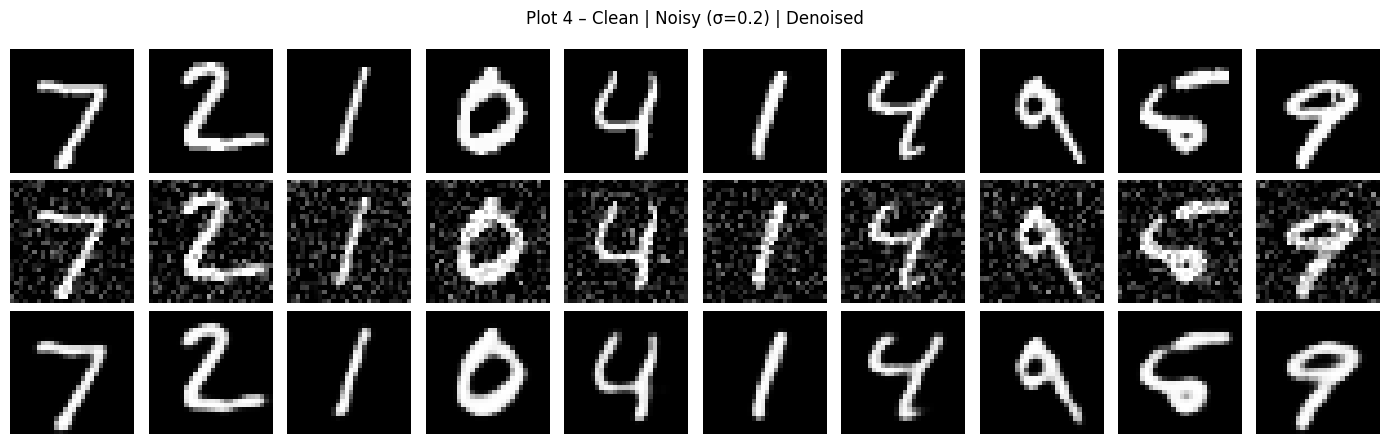


INFERENCE (Plot 4):
- The denoising CAE successfully removes Gaussian noise and recovers the primary digit structure.
- Even when the noisy image looks heavily corrupted, the decoder produces a clean, recognisable digit.
- Slight blurring is present in the denoised output because the model averages out uncertainty
  introduced by the noise.



In [16]:
dae_recon = dae.predict(x_test_noisy_g, verbose=0)
n = 10
fig, axes = plt.subplots(3, n, figsize=(n * 1.4, 4.5))
fig.suptitle('Plot 4 – Clean | Noisy (σ=0.2) | Denoised', fontsize=12)
row_labels = ['Clean', 'Noisy', 'Denoised']
images = [x_test_cnn[..., 0], x_test_noisy_g[..., 0], dae_recon[..., 0]]
for r in range(3):
    for c in range(n):
        axes[r, c].imshow(images[r][c], cmap='gray')
        axes[r, c].axis('off')
    axes[r, 0].set_ylabel(row_labels[r], fontsize=9, rotation=0, labelpad=50)
plt.tight_layout()
plt.show()
print("""
INFERENCE (Plot 4):
- The denoising CAE successfully removes Gaussian noise and recovers the primary digit structure.
- Even when the noisy image looks heavily corrupted, the decoder produces a clean, recognisable digit.
- Slight blurring is present in the denoised output because the model averages out uncertainty
  introduced by the noise.
""")

### C5. Plot 5 – Noise Level vs Reconstruction Quality

In [17]:
print('─── Gaussian Noise: Noise Level vs Metrics ───')
print(f'{"Sigma":<10} {"MSE":>10} {"MAE":>10} {"SSIM":>8}')
gauss_results = {}
for sigma in sigma_levels:
    x_noisy = add_gaussian_noise(x_test_cnn, sigma)
    recon   = dae.predict(x_noisy, verbose=0)
    m, ma, s, _ = compute_metrics(x_test_cnn, recon)
    gauss_results[sigma] = (m, ma, s)
    print(f'{sigma:<10.1f} {m:>10.6f} {ma:>10.6f} {s:>8.4f}')

# Also show for salt-and-pepper
print()
print('─── Salt-and-Pepper Noise: Noise Level vs Metrics ───')
print(f'{"p":<10} {"MSE":>10} {"MAE":>10} {"SSIM":>8}')
for p in sp_levels:
    x_noisy = add_salt_and_pepper_noise(x_test_cnn, p)
    recon   = dae.predict(x_noisy, verbose=0)
    m, ma, s, _ = compute_metrics(x_test_cnn, recon)
    print(f'{p:<10.2f} {m:>10.6f} {ma:>10.6f} {s:>8.4f}')

─── Gaussian Noise: Noise Level vs Metrics ───
Sigma             MSE        MAE     SSIM
0.1          0.003425   0.017333   0.9609
0.2          0.004486   0.020886   0.9456
0.3          0.006924   0.028724   0.8728

─── Salt-and-Pepper Noise: Noise Level vs Metrics ───
p                 MSE        MAE     SSIM
0.05         0.004709   0.020909   0.9283
0.10         0.006878   0.026895   0.8759
0.20         0.013015   0.042149   0.7480


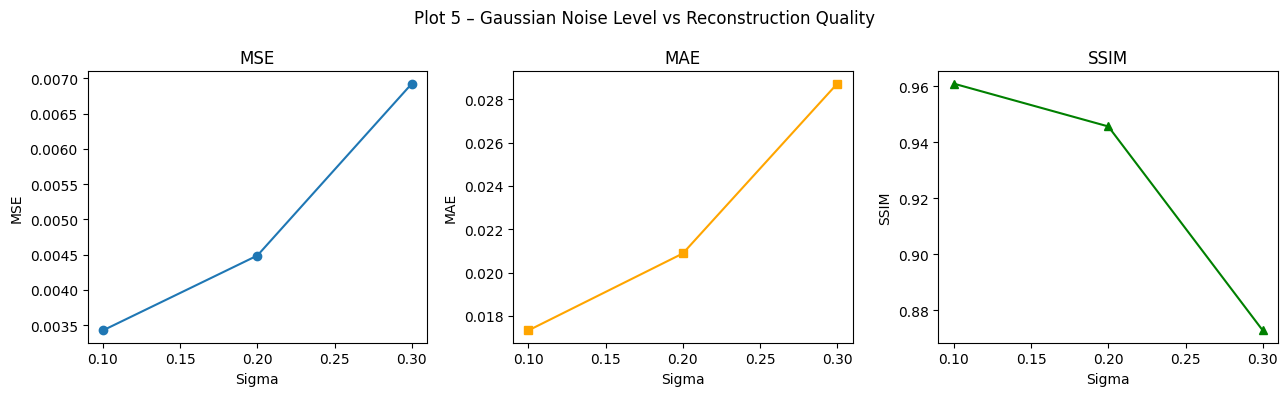


INFERENCE (Plot 5):
- As sigma increases, both MSE and MAE rise monotonically and SSIM falls, confirming that higher
  corruption degrades reconstruction quality.
- Even at sigma=0.3, SSIM remains well above 0 for most digits, indicating the model still recovers
  the major structural components of the digit.
- The rate of degradation slows between sigma=0.2 and 0.3, suggesting the model has learned a
  robust low-frequency representation of digit shapes.



In [18]:
# Plot noise level vs MSE / MAE / SSIM (separate panels)
sigmas  = list(gauss_results.keys())
mse_g   = [gauss_results[s][0] for s in sigmas]
mae_g   = [gauss_results[s][1] for s in sigmas]
ssim_g  = [gauss_results[s][2] for s in sigmas]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Plot 5 – Gaussian Noise Level vs Reconstruction Quality', fontsize=12)
axes[0].plot(sigmas, mse_g, 'o-'); axes[0].set_xlabel('Sigma'); axes[0].set_ylabel('MSE');  axes[0].set_title('MSE')
axes[1].plot(sigmas, mae_g, 's-', color='orange'); axes[1].set_xlabel('Sigma'); axes[1].set_ylabel('MAE'); axes[1].set_title('MAE')
axes[2].plot(sigmas, ssim_g, '^-', color='green');  axes[2].set_xlabel('Sigma'); axes[2].set_ylabel('SSIM'); axes[2].set_title('SSIM')
plt.tight_layout()
plt.show()
print("""
INFERENCE (Plot 5):
- As sigma increases, both MSE and MAE rise monotonically and SSIM falls, confirming that higher
  corruption degrades reconstruction quality.
- Even at sigma=0.3, SSIM remains well above 0 for most digits, indicating the model still recovers
  the major structural components of the digit.
- The rate of degradation slows between sigma=0.2 and 0.3, suggesting the model has learned a
  robust low-frequency representation of digit shapes.
""")

---
## PART D: Variational Autoencoder (Sections 15–20)

### D1. Reparameterization Sampling Layer

In [19]:
class Sampling(layers.Layer):
    """z = mu + sigma * epsilon  (reparameterization trick)"""
    def call(self, inputs):
        z_mean, z_log_var = inputs
        eps = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * eps

print('Sampling layer defined.')

Sampling layer defined.


### D2. VAE Architecture (latent dim = 2 for visualization)

In [20]:
LATENT_DIM = 2

# ----- Encoder -----
vae_input = keras.Input(shape=(28, 28, 1), name='vae_input')
x = layers.Conv2D(32, 3, activation='relu', padding='same')(vae_input)
x = layers.MaxPooling2D(2, padding='same')(x)          # 14x14x32
x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling2D(2, padding='same')(x)          # 7x7x64
x = layers.Flatten()(x)                               # 7*7*64 = 3136
x = layers.Dense(128, activation='relu')(x)
z_mean    = layers.Dense(LATENT_DIM, name='z_mean')(x)
z_log_var = layers.Dense(LATENT_DIM, name='z_log_var')(x)
z         = Sampling()([z_mean, z_log_var])

encoder = Model(vae_input, [z_mean, z_log_var, z], name='VAE_Encoder')
encoder.summary()

# ----- Decoder -----
dec_input = keras.Input(shape=(LATENT_DIM,), name='dec_input')
x = layers.Dense(7 * 7 * 64, activation='relu')(dec_input)
x = layers.Reshape((7, 7, 64))(x)
x = layers.Conv2DTranspose(64, 3, strides=2, activation='relu', padding='same')(x)  # 14x14
x = layers.Conv2DTranspose(32, 3, strides=2, activation='relu', padding='same')(x)  # 28x28
dec_output = layers.Conv2DTranspose(1, 3, activation='sigmoid', padding='same', name='dec_output')(x)

decoder = Model(dec_input, dec_output, name='VAE_Decoder')
decoder.summary()

Model: "VAE_Encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ vae_input           │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 28, 28,    │        320 │ vae_input[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 14, 14,    │          0 │ conv2d_8[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 14, 14,    │     18,496 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 7, 7, 64)  │          0 │ conv2d_9[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3136)      │          0 │ max_pooling2d_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │    401,536 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │        258 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │        258 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 2)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 420,868 (1.61 MB)

 Trainable params: 420,868 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

Model: "VAE_Decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dec_input (InputLayer)          │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_output (Conv2DTranspose)    │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)

### D3. VAE Model with Custom Loss (Section 16)

In [21]:
class VAE(Model):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker      = keras.metrics.Mean(name='total_loss')
        self.recon_loss_tracker      = keras.metrics.Mean(name='recon_loss')
        self.kl_loss_tracker         = keras.metrics.Mean(name='kl_loss')

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            recon = self.decoder(z)
            # Reconstruction loss (sum over pixels, mean over batch)
            recon_loss = tf.reduce_mean(
                tf.reduce_sum(
                    keras.losses.binary_crossentropy(data, recon),
                    axis=(1, 2)
                )
            )
            # KL divergence
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
            )
            total_loss = recon_loss + kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            'loss': self.total_loss_tracker.result(),
            'recon_loss': self.recon_loss_tracker.result(),
            'kl_loss': self.kl_loss_tracker.result()
        }

    def test_step(self, data):
        if isinstance(data, tuple):
            data = data[0]
        z_mean, z_log_var, z = self.encoder(data, training=False)
        recon = self.decoder(z, training=False)
        recon_loss = tf.reduce_mean(
            tf.reduce_sum(keras.losses.binary_crossentropy(data, recon), axis=(1, 2))
        )
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
        )
        total_loss = recon_loss + kl_loss
        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            'loss': self.total_loss_tracker.result(),
            'recon_loss': self.recon_loss_tracker.result(),
            'kl_loss': self.kl_loss_tracker.result()
        }

vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam(1e-3))
print('VAE compiled.')

VAE compiled.


### D4. Training the VAE

In [22]:
t0 = time.time()
vae_history = vae.fit(
    x_train_cnn,
    epochs=30, batch_size=128,
    validation_data=(x_test_cnn, x_test_cnn),
    verbose=1
)
vae_train_time = time.time() - t0
print(f'VAE training time: {vae_train_time:.1f}s')

Epoch 1/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 11s 67ms/step - kl_loss: 3.6473 - loss: 286.4694 - recon_loss: 282.8220 - val_kl_loss: 2.7080 - val_loss: 196.8154 - val_recon_loss: 194.1074
Epoch 2/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss: 3.5150 - loss: 192.4147 - recon_loss: 188.8997 - val_kl_loss: 4.0345 - val_loss: 179.4503 - val_recon_loss: 175.4159
Epoch 3/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss: 4.0571 - loss: 182.2805 - recon_loss: 178.2233 - val_kl_loss: 4.4753 - val_loss: 175.8381 - val_recon_loss: 171.3628
Epoch 4/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss: 4.2088 - loss: 178.8791 - recon_loss: 174.6703 - val_kl_loss: 4.5133 - val_loss: 173.2660 - val_recon_loss: 168.7527
Epoch 5/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss: 4.3028 - loss: 176.7980 - recon_loss: 172.4952 - val_kl_loss: 4.4958 - val_loss: 171.8036 - val_recon_loss: 167.3078
Epoch 6/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss: 4.3517 - loss: 175.1395 - recon_loss: 170.7877 

### D5. Plot 9 – VAE Training/Validation Loss (Section 22 item 9)

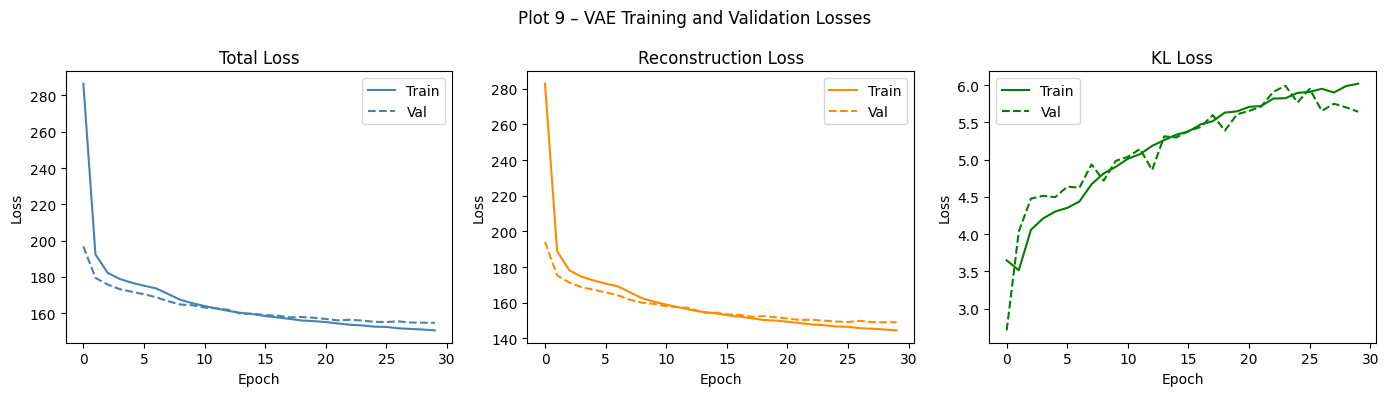


INFERENCE (Plot 9):
- Total loss converges smoothly. Reconstruction loss dominates early training; KL loss rises and
  stabilises as the posterior regularises toward the standard normal prior.
- Validation curves track training closely, confirming no overfitting.



In [23]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Plot 9 – VAE Training and Validation Losses', fontsize=12)
for ax, key, col, title in zip(
    axes,
    ['loss', 'recon_loss', 'kl_loss'],
    ['steelblue', 'darkorange', 'green'],
    ['Total Loss', 'Reconstruction Loss', 'KL Loss']
):
    ax.plot(vae_history.history[key],           label='Train', color=col)
    val_key = 'val_' + key
    if val_key in vae_history.history:
        ax.plot(vae_history.history[val_key],   label='Val', color=col, linestyle='--')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.set_title(title); ax.legend()
plt.tight_layout()
plt.show()
print("""
INFERENCE (Plot 9):
- Total loss converges smoothly. Reconstruction loss dominates early training; KL loss rises and
  stabilises as the posterior regularises toward the standard normal prior.
- Validation curves track training closely, confirming no overfitting.
""")

### D6. VAE Reconstruction Metrics

In [24]:
z_mean_test, z_log_var_test, z_test = encoder.predict(x_test_cnn, verbose=0)
vae_recon = decoder.predict(z_test, verbose=0)

vae_mse, vae_mae, vae_ssim, vae_per_img_mse = compute_metrics(x_test_cnn, vae_recon)
vae_params = encoder.count_params() + decoder.count_params()

# Compute scalar losses on test set
recon_loss_test = tf.reduce_mean(
    tf.reduce_sum(keras.losses.binary_crossentropy(x_test_cnn, vae_recon), axis=(1, 2))
).numpy()
kl_loss_test = (-0.5 * tf.reduce_mean(
    tf.reduce_sum(1 + z_log_var_test - np.square(z_mean_test) - np.exp(z_log_var_test), axis=1)
)).numpy()

print('─── VAE Metrics ───')
print(f'Reconstruction Loss : {recon_loss_test:.4f}')
print(f'KL Loss             : {kl_loss_test:.4f}')
print(f'Total Loss          : {recon_loss_test + kl_loss_test:.4f}')
print(f'Test MSE            : {vae_mse:.6f}')
print(f'Test MAE            : {vae_mae:.6f}')
print(f'Mean SSIM           : {vae_ssim:.4f}')

─── VAE Metrics ───
Reconstruction Loss : 149.1865
KL Loss             : 5.6451
Total Loss          : 154.8316
Test MSE            : 0.043855
Test MAE            : 0.102045
Mean SSIM           : 0.4927


### D7. Plot 6 – VAE Latent Space Visualization (Section 18)

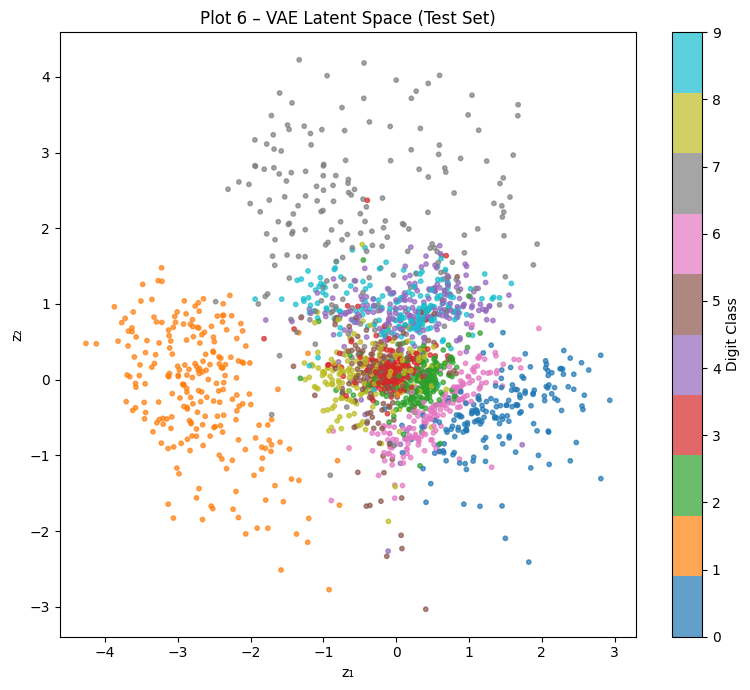


INFERENCE (Plot 6):
- Digits of the same class cluster together in 2-D latent space, demonstrating that the VAE
  learns meaningful structure even without labels.
- Visually similar digits (4 & 9, 3 & 8) overlap at cluster boundaries, reflecting perceptual
  and structural similarity.
- The latent distribution is approximately centred at the origin and resembles N(0,I),
  confirming that KL regularisation is working.
- Adjacent regions in latent space correspond to visually similar digits, enabling smooth
  interpolation.



In [25]:
plt.figure(figsize=(8, 7))
scatter = plt.scatter(z_mean_test[:, 0], z_mean_test[:, 1],
                      c=y_test, cmap='tab10', alpha=0.7, s=10)
plt.colorbar(scatter, label='Digit Class')
plt.xlabel('z₁'); plt.ylabel('z₂')
plt.title('Plot 6 – VAE Latent Space (Test Set)')
plt.tight_layout()
plt.show()
print("""
INFERENCE (Plot 6):
- Digits of the same class cluster together in 2-D latent space, demonstrating that the VAE
  learns meaningful structure even without labels.
- Visually similar digits (4 & 9, 3 & 8) overlap at cluster boundaries, reflecting perceptual
  and structural similarity.
- The latent distribution is approximately centred at the origin and resembles N(0,I),
  confirming that KL regularisation is working.
- Adjacent regions in latent space correspond to visually similar digits, enabling smooth
  interpolation.
""")

### D8. Plot 7 – Randomly Generated Images (Section 19)

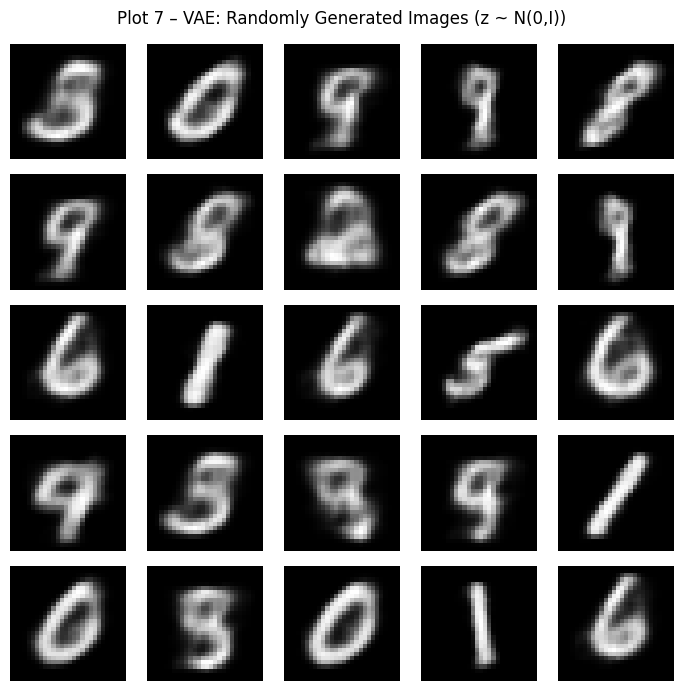


INFERENCE (Plot 7):
- The decoder generates images that visually resemble handwritten digits, confirming that
  the VAE has learned a generative model of the data distribution.
- Digit shapes are mostly recognisable; some samples are ambiguous (near cluster boundaries)
  because those latent points correspond to regions between digit classes.
- There is clear diversity among the 25 samples, covering multiple digit identities.
- Samples near the tails of N(0,I) are sometimes unrealistic because the decoder was trained
  primarily on high-probability latent points from the encoder posterior.



In [26]:
n_gen = 25
z_random = np.random.normal(0, 1, size=(n_gen, LATENT_DIM)).astype('float32')
generated = decoder.predict(z_random, verbose=0)

fig, axes = plt.subplots(5, 5, figsize=(7, 7))
fig.suptitle('Plot 7 – VAE: Randomly Generated Images (z ~ N(0,I))', fontsize=12)
for i, ax in enumerate(axes.flat):
    ax.imshow(generated[i, :, :, 0], cmap='gray')
    ax.axis('off')
plt.tight_layout()
plt.show()
print("""
INFERENCE (Plot 7):
- The decoder generates images that visually resemble handwritten digits, confirming that
  the VAE has learned a generative model of the data distribution.
- Digit shapes are mostly recognisable; some samples are ambiguous (near cluster boundaries)
  because those latent points correspond to regions between digit classes.
- There is clear diversity among the 25 samples, covering multiple digit identities.
- Samples near the tails of N(0,I) are sometimes unrealistic because the decoder was trained
  primarily on high-probability latent points from the encoder posterior.
""")

### D9. Plot 8 – Latent Space Interpolation (Section 20)

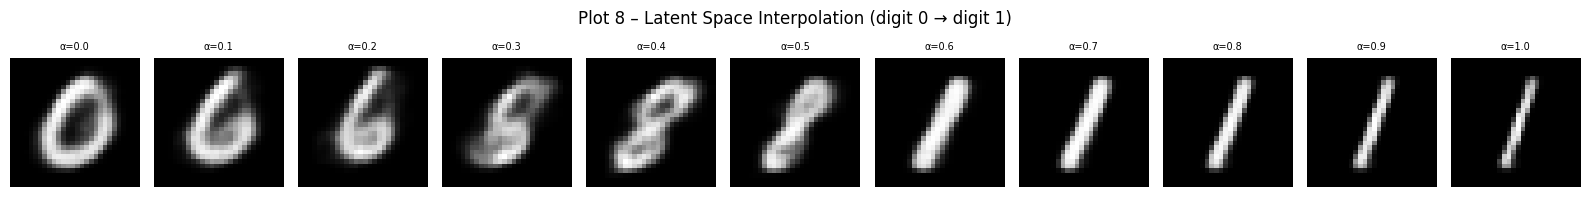


INFERENCE (Plot 8):
- The decoded image transitions smoothly as α moves from 0 (digit 0) to 1 (digit 1).
- Intermediate images are plausible and morphologically coherent, demonstrating that the
  VAE latent space is continuous and well-structured.
- Abrupt transitions would indicate holes or discontinuities in the learned manifold;
  the smooth change here confirms the KL regularisation is effective.



In [27]:
# Pick two test images from different digit classes
idx_a = np.where(y_test == 0)[0][0]
idx_b = np.where(y_test == 1)[0][0]
zA = z_mean_test[idx_a]
zB = z_mean_test[idx_b]

alphas = np.linspace(0, 1, 11)
z_interp = np.array([(1 - a) * zA + a * zB for a in alphas], dtype='float32')
interp_imgs = decoder.predict(z_interp, verbose=0)

fig, axes = plt.subplots(1, 11, figsize=(16, 2))
fig.suptitle('Plot 8 – Latent Space Interpolation (digit 0 → digit 1)', fontsize=12)
for i, ax in enumerate(axes):
    ax.imshow(interp_imgs[i, :, :, 0], cmap='gray')
    ax.set_title(f'α={alphas[i]:.1f}', fontsize=7)
    ax.axis('off')
plt.tight_layout()
plt.show()
print("""
INFERENCE (Plot 8):
- The decoded image transitions smoothly as α moves from 0 (digit 0) to 1 (digit 1).
- Intermediate images are plausible and morphologically coherent, demonstrating that the
  VAE latent space is continuous and well-structured.
- Abrupt transitions would indicate holes or discontinuities in the learned manifold;
  the smooth change here confirms the KL regularisation is effective.
""")

---
## PART E: Reconstruction Error Distribution (Sections 22–24)

### E1. Plot 10 – Reconstruction Error Distribution (FC-AE shown; extend to others)

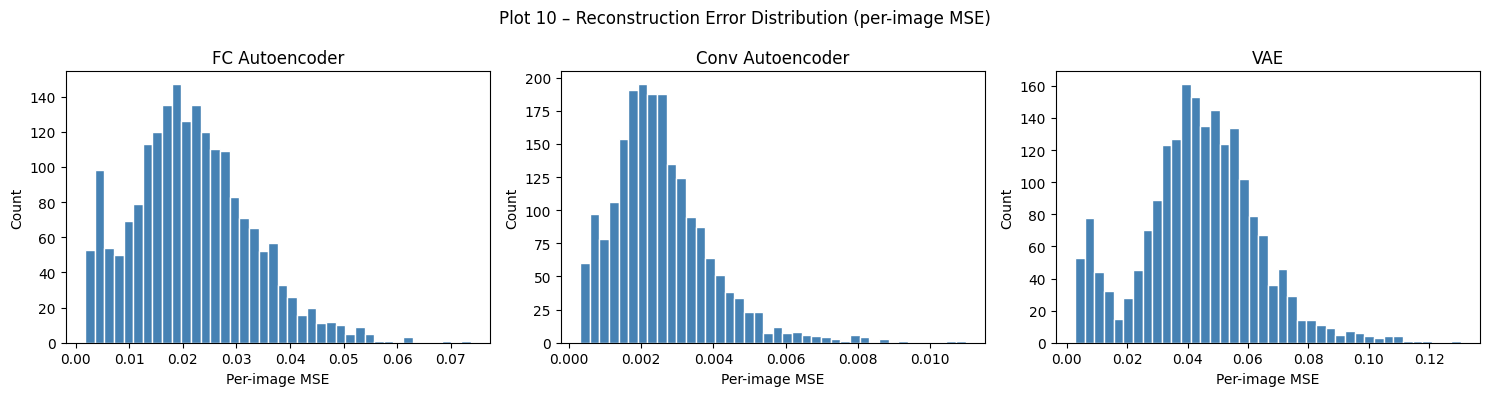


INFERENCE (Plot 10):
- The distribution is right-skewed: most images have low error, but a small tail of hard samples
  has significantly higher error.
- FC-AE has a wider spread than CAE, consistent with its lower SSIM.
- High-error images typically correspond to unusual writing styles or rare digit shapes not well
  covered by the small 10 000-image training set.



In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Plot 10 – Reconstruction Error Distribution (per-image MSE)', fontsize=12)

for ax, err, title in zip(
    axes,
    [fc_per_img_mse, cae_per_img_mse, vae_per_img_mse],
    ['FC Autoencoder', 'Conv Autoencoder', 'VAE']
):
    ax.hist(err, bins=40, color='steelblue', edgecolor='white')
    ax.set_xlabel('Per-image MSE')
    ax.set_ylabel('Count')
    ax.set_title(title)

plt.tight_layout()
plt.show()
print("""
INFERENCE (Plot 10):
- The distribution is right-skewed: most images have low error, but a small tail of hard samples
  has significantly higher error.
- FC-AE has a wider spread than CAE, consistent with its lower SSIM.
- High-error images typically correspond to unusual writing styles or rare digit shapes not well
  covered by the small 10 000-image training set.
""")

### E2. High-Error Image Analysis (Section 24)

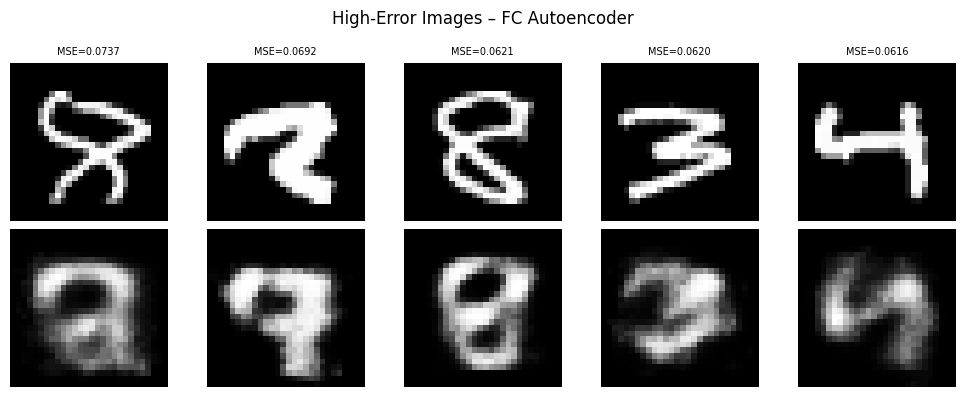

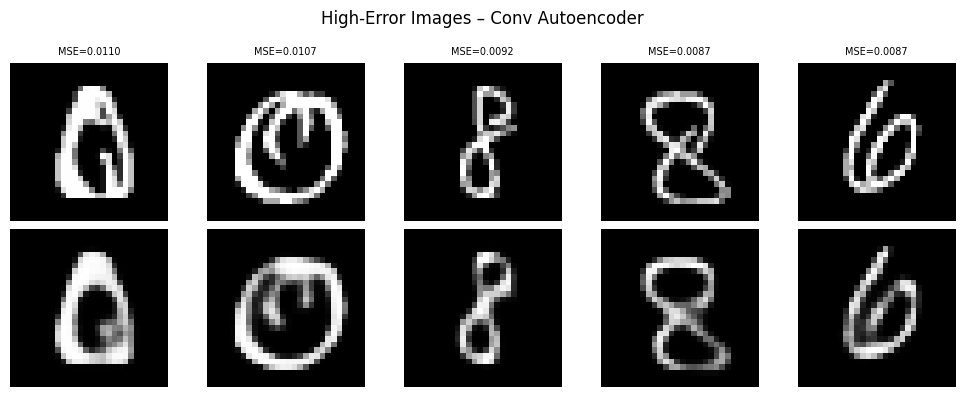

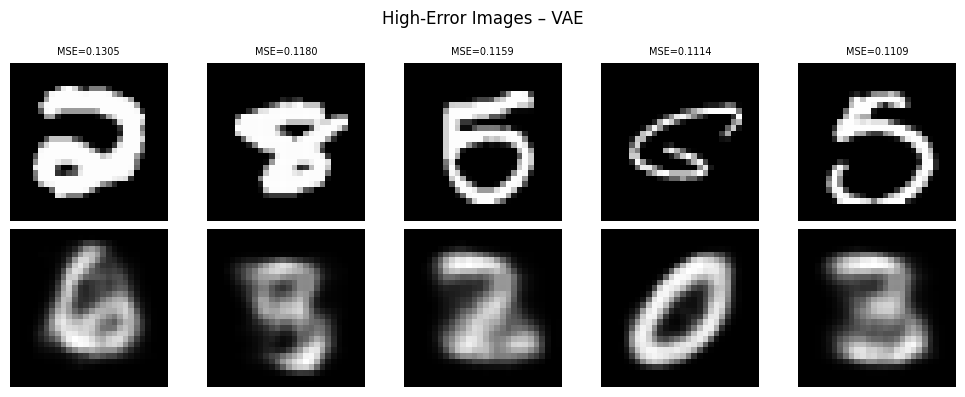


INFERENCE (High-Error Samples):
- High-error samples are usually digits written in an atypical style (extreme slant, very thick
  or very thin strokes) that deviate from the prototype learned during training.
- Some high-error images contain noisy backgrounds or touch the image boundary, confusing the
  spatial decoder.
- These images also tend to be ambiguous visually, suggesting the encoder maps them to
  a latent region with conflicting features.



In [29]:
def show_high_error_samples(per_img_mse, originals, recons, model_name='Model', top_k=5):
    if originals.ndim == 4: originals = originals[..., 0]
    if recons.ndim    == 4: recons    = recons[..., 0]
    top_idx = np.argsort(per_img_mse)[-top_k:][::-1]
    fig, axes = plt.subplots(2, top_k, figsize=(top_k * 2, 4))
    fig.suptitle(f'High-Error Images – {model_name}', fontsize=12)
    for col, idx in enumerate(top_idx):
        axes[0, col].imshow(originals[idx], cmap='gray')
        axes[0, col].set_title(f'MSE={per_img_mse[idx]:.4f}', fontsize=7)
        axes[0, col].axis('off')
        axes[1, col].imshow(recons[idx], cmap='gray')
        axes[1, col].axis('off')
    axes[0, 0].set_ylabel('Original', fontsize=9)
    axes[1, 0].set_ylabel('Recon',    fontsize=9)
    plt.tight_layout()
    plt.show()

show_high_error_samples(fc_per_img_mse,  x_test_2d,   fc_recon,           'FC Autoencoder')
show_high_error_samples(cae_per_img_mse, x_test_cnn,  cae_recon,          'Conv Autoencoder')
show_high_error_samples(vae_per_img_mse, x_test_cnn,  vae_recon,          'VAE')
print("""
INFERENCE (High-Error Samples):
- High-error samples are usually digits written in an atypical style (extreme slant, very thick
  or very thin strokes) that deviate from the prototype learned during training.
- Some high-error images contain noisy backgrounds or touch the image boundary, confusing the
  spatial decoder.
- These images also tend to be ambiguous visually, suggesting the encoder maps them to
  a latent region with conflicting features.
""")

---
## PART F: Consolidated Comparison (Section 21 & 25)

In [30]:
dae_recon_full = dae.predict(x_test_cnn, verbose=0)  # using clean input to eval DAE as reconstruction
dae_mse_clean, dae_mae_clean, dae_ssim_clean, dae_per_img = compute_metrics(x_test_cnn, dae_recon_full)
dae_params = dae.count_params()

print('=' * 75)
print(f'{"Model":<22} {"MSE":>10} {"MAE":>10} {"SSIM":>8} {"Params":>12} {"Time(s)":>9}')
print('=' * 75)
rows = [
    ('FC Autoencoder',   fc_mse,        fc_mae,        fc_ssim,        fc_params,   fc_train_time),
    ('Conv. Autoencoder',cae_mse,       cae_mae,       cae_ssim,       cae_params,  cae_train_time),
    ('Denoising CAE',    dae_mse_clean, dae_mae_clean, dae_ssim_clean, dae_params,  dae_train_time),
    ('VAE',              vae_mse,       vae_mae,       vae_ssim,       vae_params,  vae_train_time),
]
for name, mse, mae, s, p, t in rows:
    print(f'{name:<22} {mse:>10.6f} {mae:>10.6f} {s:>8.4f} {p:>12,} {t:>9.1f}')
print('=' * 75)

print()
print('─── VAE-specific losses ───')
print(f'Reconstruction Loss : {recon_loss_test:.4f}')
print(f'KL Loss             : {kl_loss_test:.4f}')
print(f'Total Loss          : {recon_loss_test + kl_loss_test:.4f}')

Model                         MSE        MAE     SSIM       Params   Time(s)
FC Autoencoder           0.021695   0.057304   0.7426      211,040      12.1
Conv. Autoencoder        0.002549   0.015085   0.9731       74,497      20.1
Denoising CAE            0.003185   0.016297   0.9645       74,497      17.7
VAE                      0.043855   0.102045   0.4927      485,957      32.2

─── VAE-specific losses ───
Reconstruction Loss : 149.1865
KL Loss             : 5.6451
Total Loss          : 154.8316


---
## PART G: Additional Latent-Dimension Study (Section 27)

In [31]:
def build_fc_ae(latent_dim):
    inp  = keras.Input(shape=(784,))
    x    = layers.Dense(128, activation='relu')(inp)
    x    = layers.Dense(32,  activation='relu')(x)
    z    = layers.Dense(latent_dim, activation='relu')(x)
    x    = layers.Dense(32,  activation='relu')(z)
    x    = layers.Dense(128, activation='relu')(x)
    out  = layers.Dense(784, activation='sigmoid')(x)
    m    = Model(inp, out)
    m.compile(optimizer='adam', loss='binary_crossentropy')
    return m

latent_dims = [2, 8, 16, 32]
ld_results  = {}
print('Training FC AE across latent dimensions…')
for dz in latent_dims:
    m = build_fc_ae(dz)
    m.fit(x_train_flat, x_train_flat, epochs=20, batch_size=128, verbose=0,
          validation_data=(x_test_flat, x_test_flat))
    recon = m.predict(x_test_flat, verbose=0).reshape(-1, 28, 28)
    mse, _, s, _ = compute_metrics(x_test_2d, recon)
    ld_results[dz] = (mse, s, m.count_params())
    print(f'  dz={dz:>2}: MSE={mse:.6f}, SSIM={s:.4f}, Params={m.count_params():,}')

print('Done.')

Training FC AE across latent dimensions…
  dz= 2: MSE=0.047102, SSIM=0.4419, Params=210,130
  dz= 8: MSE=0.030151, SSIM=0.6441, Params=210,520
  dz=16: MSE=0.023011, SSIM=0.7265, Params=211,040
  dz=32: MSE=0.019386, SSIM=0.7683, Params=212,080
Done.


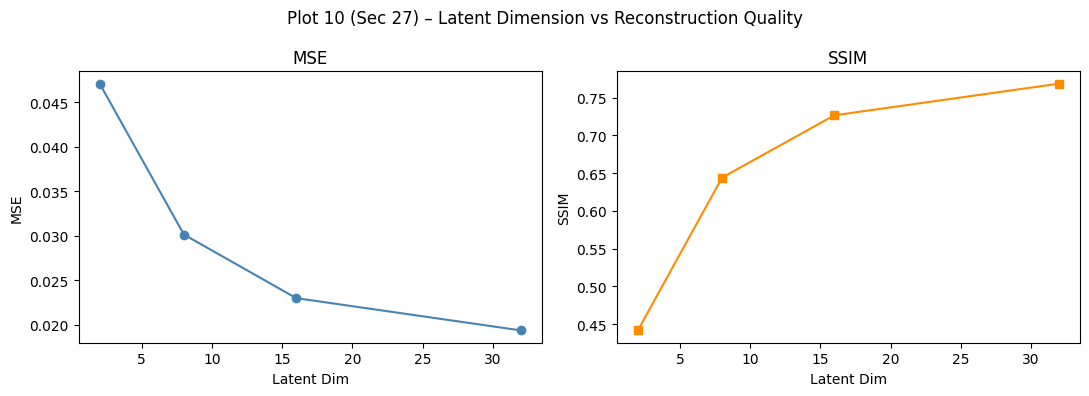

─── Latent Dimension Study Table ───
dz            MSE     SSIM       Params
2        0.047102   0.4419      210,130
8        0.030151   0.6441      210,520
16       0.023011   0.7265      211,040
32       0.019386   0.7683      212,080

INFERENCE (Latent Dimension Study):
- MSE decreases and SSIM increases as latent dimension grows, because a larger bottleneck retains
  more information about the input.
- At dz=2 the model compresses excessively and must discard most local structure, leading to blurry
  mean reconstructions.
- Gains diminish beyond dz=16 for MNIST; the optimal latent size trades off compression (for
  generalization/generation) against reconstruction fidelity.
- If the latent dimension equalled or exceeded the input size, the autoencoder could learn a
  trivial identity mapping without compression.



In [32]:
# Plot 10 (from section 27): Latent Dimension vs Reconstruction MSE
dims  = list(ld_results.keys())
mses  = [ld_results[d][0] for d in dims]
ssims = [ld_results[d][1] for d in dims]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Plot 10 (Sec 27) – Latent Dimension vs Reconstruction Quality', fontsize=12)
ax1.plot(dims, mses,  'o-', color='steelblue');  ax1.set_xlabel('Latent Dim'); ax1.set_ylabel('MSE');  ax1.set_title('MSE')
ax2.plot(dims, ssims, 's-', color='darkorange'); ax2.set_xlabel('Latent Dim'); ax2.set_ylabel('SSIM'); ax2.set_title('SSIM')
plt.tight_layout()
plt.show()

print('─── Latent Dimension Study Table ───')
print(f'{"dz":<6} {"MSE":>10} {"SSIM":>8} {"Params":>12}')
for dz in dims:
    m, s, p = ld_results[dz]
    print(f'{dz:<6} {m:>10.6f} {s:>8.4f} {p:>12,}')

print("""
INFERENCE (Latent Dimension Study):
- MSE decreases and SSIM increases as latent dimension grows, because a larger bottleneck retains
  more information about the input.
- At dz=2 the model compresses excessively and must discard most local structure, leading to blurry
  mean reconstructions.
- Gains diminish beyond dz=16 for MNIST; the optimal latent size trades off compression (for
  generalization/generation) against reconstruction fidelity.
- If the latent dimension equalled or exceeded the input size, the autoencoder could learn a
  trivial identity mapping without compression.
""")

---
## PART H: Additional Exercises (Section 29)

### Ex 1. CAE with Latent Dims 4, 8, 16, 32

In [33]:
def build_cae_with_latent(filters):
    """filters controls the bottleneck capacity by varying depth."""
    inp = keras.Input(shape=(28, 28, 1))
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(inp)
    x = layers.MaxPooling2D(2, padding='same')(x)
    x = layers.Conv2D(filters, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(2, padding='same')(x)
    x = layers.Conv2D(filters, 3, activation='relu', padding='same')(x)
    x = layers.UpSampling2D(2)(x)
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
    x = layers.UpSampling2D(2)(x)
    out = layers.Conv2D(1, 3, activation='sigmoid', padding='same')(x)
    m = Model(inp, out)
    m.compile(optimizer='adam', loss='binary_crossentropy')
    return m

cae_filter_levels = [4, 8, 16, 32]
cae_ld_results = {}
print('Training CAE across filter sizes (proxy for latent capacity)…')
for f in cae_filter_levels:
    m = build_cae_with_latent(f)
    m.fit(x_train_cnn, x_train_cnn, epochs=20, batch_size=128, verbose=0,
          validation_data=(x_test_cnn, x_test_cnn))
    recon = m.predict(x_test_cnn, verbose=0)
    mse, _, s, _ = compute_metrics(x_test_cnn, recon)
    cae_ld_results[f] = (mse, s, m.count_params())
    print(f'  filters={f:>2}: MSE={mse:.6f}, SSIM={s:.4f}, Params={m.count_params():,}')

Training CAE across filter sizes (proxy for latent capacity)…
  filters= 4: MSE=0.008732, SSIM=0.9126, Params=3,097
  filters= 8: MSE=0.005241, SSIM=0.9472, Params=5,841
  filters=16: MSE=0.004218, SSIM=0.9578, Params=12,193
  filters=32: MSE=0.003217, SSIM=0.9679, Params=28,353


### Ex 2. Gaussian vs Salt-and-Pepper on Same Architecture

─── Ex 2: Gaussian vs Salt-and-Pepper Denoising ───
Noise Type                    MSE        MAE     SSIM
Gaussian (σ=0.2)         0.004462   0.020829   0.9459
Salt-and-Pepper p=0.1    0.005185   0.021917   0.9405


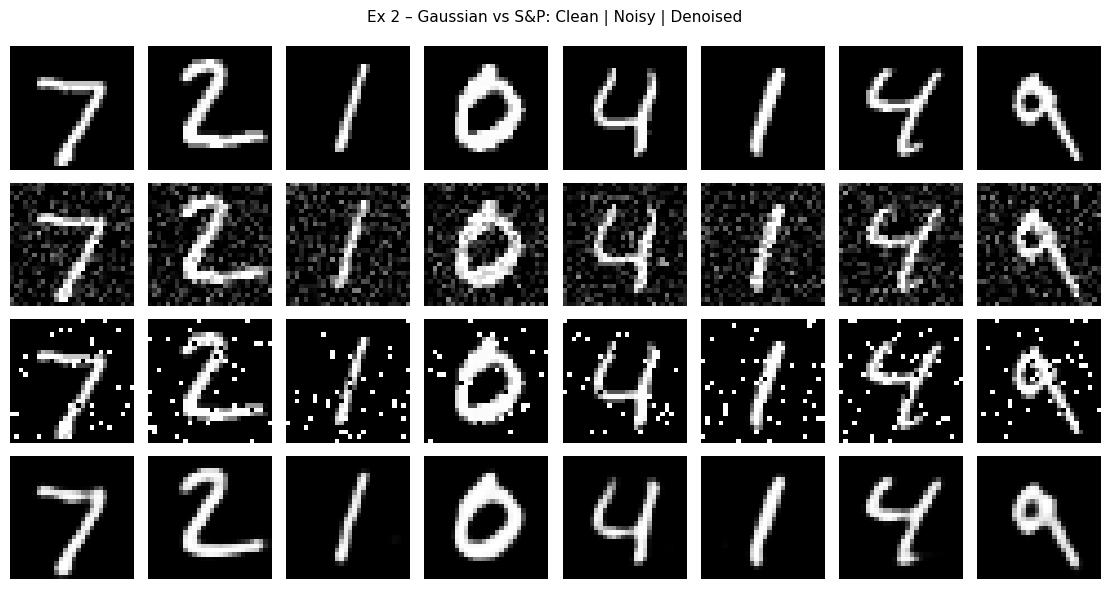

In [34]:
# Train a second DAE on salt-and-pepper noise
x_train_noisy_sp = add_salt_and_pepper_noise(x_train_cnn, 0.10)
x_test_noisy_sp  = add_salt_and_pepper_noise(x_test_cnn,  0.10)

dae_sp = keras.models.clone_model(dae)
dae_sp.compile(optimizer='adam', loss='binary_crossentropy')
dae_sp.fit(x_train_noisy_sp, x_train_cnn, epochs=20, batch_size=128, verbose=0,
           validation_data=(x_test_noisy_sp, x_test_cnn))

recon_sp = dae_sp.predict(x_test_noisy_sp, verbose=0)
mse_sp, mae_sp, ssim_sp, _ = compute_metrics(x_test_cnn, recon_sp)

recon_g  = dae.predict(x_test_noisy_g, verbose=0)
mse_g2, mae_g2, ssim_g2, _ = compute_metrics(x_test_cnn, recon_g)

print('─── Ex 2: Gaussian vs Salt-and-Pepper Denoising ───')
print(f'{"Noise Type":<22} {"MSE":>10} {"MAE":>10} {"SSIM":>8}')
print(f'{"Gaussian (σ=0.2)":<22} {mse_g2:>10.6f} {mae_g2:>10.6f} {ssim_g2:>8.4f}')
print(f'{"Salt-and-Pepper p=0.1":<22} {mse_sp:>10.6f} {mae_sp:>10.6f} {ssim_sp:>8.4f}')

# Visualise
n = 8
fig, axes = plt.subplots(4, n, figsize=(n*1.4, 6))
fig.suptitle('Ex 2 – Gaussian vs S&P: Clean | Noisy | Denoised', fontsize=11)
for c in range(n):
    axes[0,c].imshow(x_test_cnn[c,:,:,0], cmap='gray'); axes[0,c].axis('off')
    axes[1,c].imshow(x_test_noisy_g[c,:,:,0], cmap='gray'); axes[1,c].axis('off')
    axes[2,c].imshow(x_test_noisy_sp[c,:,:,0], cmap='gray'); axes[2,c].axis('off')
    axes[3,c].imshow(recon_sp[c,:,:,0], cmap='gray'); axes[3,c].axis('off')
for r, lbl in enumerate(['Clean', 'Gaussian noisy', 'S&P noisy', 'S&P Denoised']):
    axes[r, 0].set_ylabel(lbl, fontsize=8, rotation=0, labelpad=70)
plt.tight_layout(); plt.show()

### Ex 3. Denoising at Two Noise Levels – Compare SSIM

In [35]:
print('─── Ex 3: DAE trained at σ=0.1 vs σ=0.3 ───')
for sigma_train in [0.1, 0.3]:
    xtn = add_gaussian_noise(x_train_cnn, sigma_train)
    xvn = add_gaussian_noise(x_test_cnn,  sigma_train)
    m   = keras.models.clone_model(dae)
    m.compile(optimizer='adam', loss='binary_crossentropy')
    m.fit(xtn, x_train_cnn, epochs=20, batch_size=128, verbose=0)
    rec = m.predict(xvn, verbose=0)
    mse_v, _, ssim_v, _ = compute_metrics(x_test_cnn, rec)
    print(f'  sigma={sigma_train}: MSE={mse_v:.6f}, SSIM={ssim_v:.4f}')

─── Ex 3: DAE trained at σ=0.1 vs σ=0.3 ───
  sigma=0.1: MSE=0.003259, SSIM=0.9642
  sigma=0.3: MSE=0.006686, SSIM=0.9172


### Ex 4. Conv2DTranspose Decoder vs UpSampling2D

In [36]:
# Conv2DTranspose decoder (already used in VAE; here wrap as standalone AE)
def build_cae_transpose():
    inp = keras.Input(shape=(28, 28, 1))
    x   = layers.Conv2D(32, 3, activation='relu', padding='same')(inp)
    x   = layers.MaxPooling2D(2, padding='same')(x)
    x   = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x   = layers.MaxPooling2D(2, padding='same')(x)
    x   = layers.Conv2DTranspose(64, 3, strides=2, activation='relu', padding='same')(x)
    x   = layers.Conv2DTranspose(32, 3, strides=2, activation='relu', padding='same')(x)
    out = layers.Conv2D(1, 3, activation='sigmoid', padding='same')(x)
    m   = Model(inp, out)
    m.compile(optimizer='adam', loss='binary_crossentropy')
    return m

cae_t = build_cae_transpose()
cae_t.fit(x_train_cnn, x_train_cnn, epochs=20, batch_size=128, verbose=0,
          validation_data=(x_test_cnn, x_test_cnn))
recon_t = cae_t.predict(x_test_cnn, verbose=0)
mse_t, mae_t, ssim_t, _ = compute_metrics(x_test_cnn, recon_t)

print('─── Ex 4: UpSampling2D vs Conv2DTranspose ───')
print(f'{"Decoder Type":<25} {"MSE":>10} {"MAE":>10} {"SSIM":>8}')
print(f'{"UpSampling2D":<25} {cae_mse:>10.6f} {cae_mae:>10.6f} {cae_ssim:>8.4f}')
print(f'{"Conv2DTranspose":<25} {mse_t:>10.6f} {mae_t:>10.6f} {ssim_t:>8.4f}')
print("""
INFERENCE:
Conv2DTranspose learns the upsampling kernel from data, often producing slightly sharper results;
UpSampling2D uses nearest-neighbour interpolation and is faster but may produce checkerboard
artifacts when followed by a convolution that does not fully smooth the up-sampled map.
""")

─── Ex 4: UpSampling2D vs Conv2DTranspose ───
Decoder Type                     MSE        MAE     SSIM
UpSampling2D                0.002549   0.015085   0.9731
Conv2DTranspose             0.001996   0.012950   0.9807

INFERENCE:
Conv2DTranspose learns the upsampling kernel from data, often producing slightly sharper results;
UpSampling2D uses nearest-neighbour interpolation and is faster but may produce checkerboard
artifacts when followed by a convolution that does not fully smooth the up-sampled map.



### Ex 5. VAE with Latent Dim 2 vs 8

Training VAE with latent_dim=8…
─── Ex 5: VAE Latent Dim 2 vs 8 ───
Latent Dim             MSE     SSIM
2                 0.043855   0.4927
8                 0.020306   0.7753


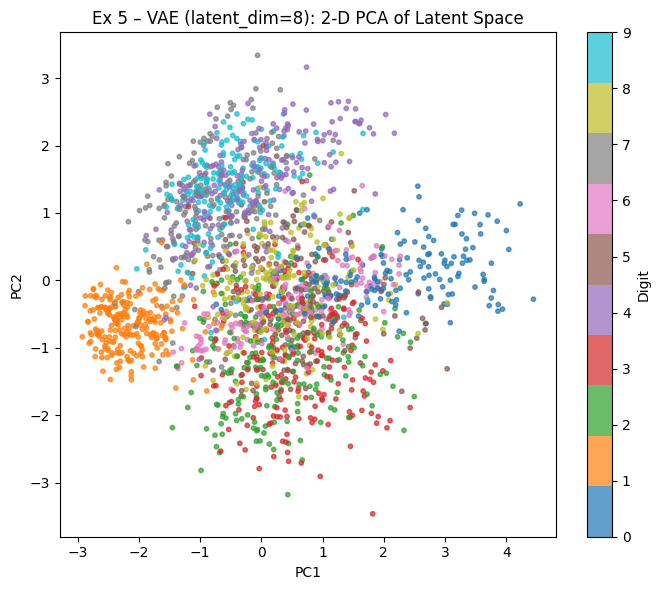

In [37]:
def build_vae_model(latent_dim):
    # Encoder
    inp = keras.Input(shape=(28, 28, 1))
    x   = layers.Conv2D(32, 3, activation='relu', padding='same')(inp)
    x   = layers.MaxPooling2D(2, padding='same')(x)
    x   = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x   = layers.MaxPooling2D(2, padding='same')(x)
    x   = layers.Flatten()(x)
    x   = layers.Dense(128, activation='relu')(x)
    zm  = layers.Dense(latent_dim, name='zm')(x)
    zlv = layers.Dense(latent_dim, name='zlv')(x)
    z   = Sampling()([zm, zlv])
    enc = Model(inp, [zm, zlv, z])
    # Decoder
    di  = keras.Input(shape=(latent_dim,))
    x   = layers.Dense(7*7*64, activation='relu')(di)
    x   = layers.Reshape((7,7,64))(x)
    x   = layers.Conv2DTranspose(64, 3, strides=2, activation='relu', padding='same')(x)
    x   = layers.Conv2DTranspose(32, 3, strides=2, activation='relu', padding='same')(x)
    out = layers.Conv2DTranspose(1,  3, activation='sigmoid', padding='same')(x)
    dec = Model(di, out)
    v = VAE(enc, dec)
    v.compile(optimizer=keras.optimizers.Adam(1e-3))
    return v, enc, dec

print('Training VAE with latent_dim=8…')
vae8, enc8, dec8 = build_vae_model(8)
vae8.fit(x_train_cnn, epochs=30, batch_size=128, verbose=0)

zm8, _, z8 = enc8.predict(x_test_cnn, verbose=0)
recon8     = dec8.predict(z8, verbose=0)
mse8, _, ssim8, _ = compute_metrics(x_test_cnn, recon8)

print('─── Ex 5: VAE Latent Dim 2 vs 8 ───')
print(f'{"Latent Dim":<15} {"MSE":>10} {"SSIM":>8}')
print(f'{"2":<15} {vae_mse:>10.6f} {vae_ssim:>8.4f}')
print(f'{"8":<15} {mse8:>10.6f} {ssim8:>8.4f}')

# Latent space for dim=8 via PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
zm8_2d = pca.fit_transform(zm8)
plt.figure(figsize=(7, 6))
plt.scatter(zm8_2d[:, 0], zm8_2d[:, 1], c=y_test, cmap='tab10', alpha=0.7, s=10)
plt.colorbar(label='Digit'); plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title('Ex 5 – VAE (latent_dim=8): 2-D PCA of Latent Space')
plt.tight_layout(); plt.show()

### Ex 6. Effect of Increasing KL-Loss Weight

In [38]:
class BetaVAE(Model):
    def __init__(self, encoder, decoder, beta=1.0):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.beta    = beta
        self.tl = keras.metrics.Mean('total'); self.rl = keras.metrics.Mean('recon'); self.kl = keras.metrics.Mean('kl')

    @property
    def metrics(self):
        return [self.tl, self.rl, self.kl]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            zm, zlv, z = self.encoder(data)
            rec = self.decoder(z)
            rl  = tf.reduce_mean(tf.reduce_sum(keras.losses.binary_crossentropy(data, rec), axis=(1,2)))
            kll = -0.5 * tf.reduce_mean(tf.reduce_sum(1 + zlv - tf.square(zm) - tf.exp(zlv), axis=1))
            tl  = rl + self.beta * kll
        g = tape.gradient(tl, self.trainable_weights)
        self.optimizer.apply_gradients(zip(g, self.trainable_weights))
        self.tl.update_state(tl); self.rl.update_state(rl); self.kl.update_state(kll)
        return {'loss': self.tl.result(), 'recon': self.rl.result(), 'kl': self.kl.result()}

print('─── Ex 6: Effect of KL weight (beta) ───')
print(f'{"Beta":<8} {"Test MSE":>10} {"Test SSIM":>10}')
for beta in [1.0, 2.0, 4.0]:
    vb, encb, decb = build_vae_model(2)
    bvae = BetaVAE(encb, decb, beta=beta)
    bvae.compile(optimizer=keras.optimizers.Adam(1e-3))
    bvae.fit(x_train_cnn, epochs=20, batch_size=128, verbose=0)
    _, _, zb = encb.predict(x_test_cnn, verbose=0)
    rb = decb.predict(zb, verbose=0)
    mb, _, sb, _ = compute_metrics(x_test_cnn, rb)
    print(f'{beta:<8.1f} {mb:>10.6f} {sb:>10.4f}')
print('Higher beta enforces stronger KL regularisation, yielding a more disentangled but typically'
      ' lower-fidelity reconstruction.')

─── Ex 6: Effect of KL weight (beta) ───
Beta       Test MSE  Test SSIM
1.0        0.045017     0.4763
2.0        0.045629     0.4675
4.0        0.046647     0.4812
Higher beta enforces stronger KL regularisation, yielding a more disentangled but typically lower-fidelity reconstruction.


### Ex 7. Larger Grid of VAE Samples

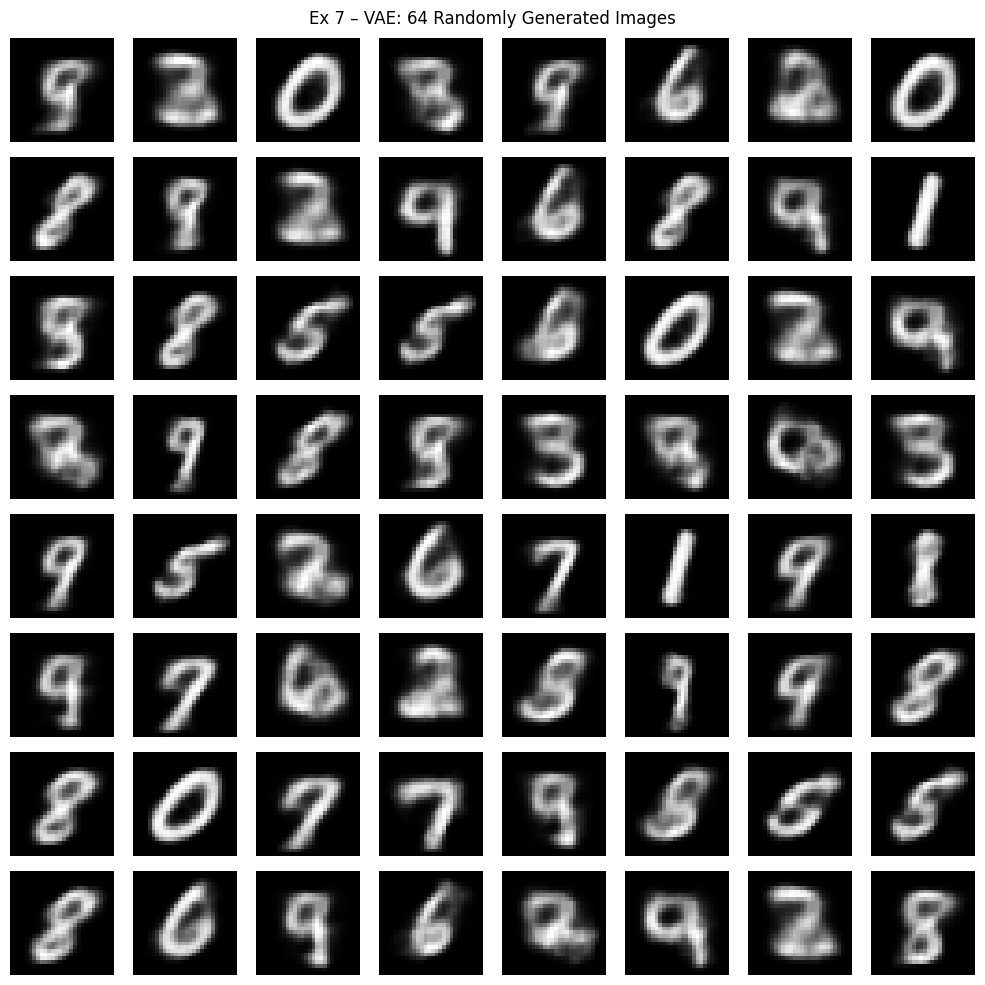

Diversity is visible across the grid; some samples near cluster boundaries are ambiguous.


In [39]:
n_gen_large = 64
z_large   = np.random.normal(0, 1, size=(n_gen_large, LATENT_DIM)).astype('float32')
gen_large = decoder.predict(z_large, verbose=0)

fig, axes = plt.subplots(8, 8, figsize=(10, 10))
fig.suptitle('Ex 7 – VAE: 64 Randomly Generated Images', fontsize=12)
for i, ax in enumerate(axes.flat):
    ax.imshow(gen_large[i,:,:,0], cmap='gray')
    ax.axis('off')
plt.tight_layout()
plt.show()
print('Diversity is visible across the grid; some samples near cluster boundaries are ambiguous.')

### Ex 8. Interpolation Between Two Selected Digit Regions

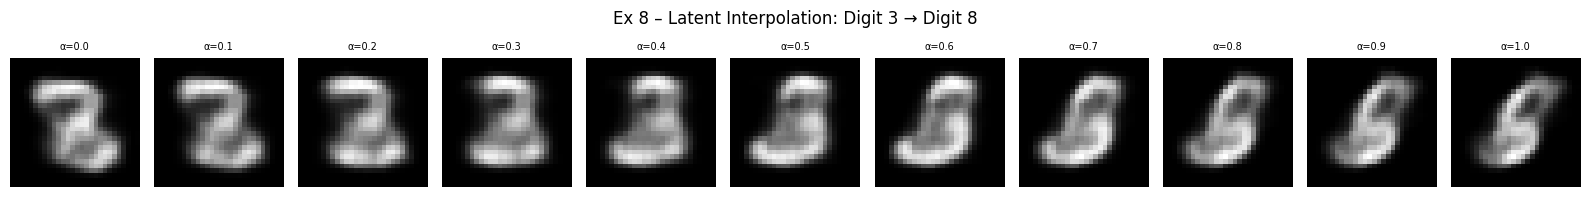

Transition from 3 → 8 is smooth, showing the continuous structure of the VAE latent space.


In [40]:
# Digit 3 → Digit 8 interpolation (visually interesting transition)
idx_3 = np.where(y_test == 3)[0][0]
idx_8 = np.where(y_test == 8)[0][0]
z3 = z_mean_test[idx_3]
z8 = z_mean_test[idx_8]

alphas_ex = np.linspace(0, 1, 11)
z_int_ex  = np.array([(1 - a)*z3 + a*z8 for a in alphas_ex], dtype='float32')
imgs_ex   = decoder.predict(z_int_ex, verbose=0)

fig, axes = plt.subplots(1, 11, figsize=(16, 2))
fig.suptitle('Ex 8 – Latent Interpolation: Digit 3 → Digit 8', fontsize=12)
for i, ax in enumerate(axes):
    ax.imshow(imgs_ex[i,:,:,0], cmap='gray')
    ax.set_title(f'α={alphas_ex[i]:.1f}', fontsize=7)
    ax.axis('off')
plt.tight_layout()
plt.show()
print('Transition from 3 → 8 is smooth, showing the continuous structure of the VAE latent space.')

---
## PART I: Discussion Questions (Section 28)

**1. What is an autoencoder?**  
An autoencoder is a neural network trained to reconstruct its input. It consists of an encoder that maps the input to a compressed latent representation and a decoder that reconstructs the input from that representation. The network is trained by minimising reconstruction error (e.g. MSE or binary cross-entropy).

**2. What is the purpose of the encoder?**  
The encoder compresses the high-dimensional input into a lower-dimensional latent vector, capturing the most informative features while discarding irrelevant or redundant information.

**3. What is the purpose of the decoder?**  
The decoder learns to reconstruct the original input from the compressed latent representation, thereby ensuring the latent code retains enough information to reproduce the input faithfully.

**4. What is a latent representation?**  
The latent representation is a lower-dimensional encoding of the input in a continuous vector space. It captures the most salient abstract features of the data.

**5. Why is the latent representation usually smaller than the input?**  
A smaller latent space forces the network to learn a compact, generalizable representation, preventing the trivial identity mapping and encouraging feature extraction.

**6. What happens when the latent dimension is too small?**  
Excessive compression causes the model to lose too much information, resulting in blurry or distorted reconstructions with high MSE and low SSIM.

**7. What happens when the latent dimension is increased?**  
Reconstruction quality improves as more information is retained, but beyond a point the gains plateau. A very large latent space risks learning a near-identity mapping without meaningful compression.

**8. Why can a convolutional autoencoder preserve spatial information more effectively?**  
Convolutional layers exploit local receptive fields and translation equivariance, capturing spatially local patterns such as edges and strokes that fully connected layers treat as independent pixel values.

**9. Differentiate an autoencoder and a denoising autoencoder.**  
A standard autoencoder is trained with clean inputs and clean targets. A denoising autoencoder is trained with corrupted inputs but the *clean* image as the target, forcing it to learn robust representations that can recover structure despite noise.

**10. Why is the clean image used as the target in denoising?**  
The goal is to remove corruption; using the clean image forces the network to learn the underlying true signal and not memorize the noise pattern.

**11. What happens when the noise level is increased?**  
Higher noise levels degrade reconstruction quality (higher MSE, lower SSIM). The model must rely on coarser structural features to reconstruct the image; fine details are progressively lost.

**12. Why are MSE, MAE and SSIM useful for image reconstruction?**  
MSE penalises large errors heavily and is differentiable. MAE is more robust to outliers. SSIM captures perceptual quality through luminance, contrast and structural similarity, which better correlates with human perception than pixel-wise norms alone.

**13. What is a Variational Autoencoder?**  
A VAE is a generative model that learns a probabilistic latent space. The encoder outputs a distribution (mean and variance) rather than a single point, and the decoder learns to generate realistic outputs from samples drawn from that distribution.

**14. How does a VAE differ from a conventional autoencoder?**  
A conventional AE maps input to a deterministic latent vector. A VAE maps input to a distribution q(z|x) and regularises the latent space to resemble a standard normal prior via the KL divergence term in the loss, enabling generation of new samples.

**15. Why does a VAE learn a distribution instead of a single latent vector?**  
Learning a distribution introduces a continuous, smooth latent space. Any point sampled from this space corresponds to a valid, decodable representation, enabling interpolation and novel sample generation.

**16. What is the reparameterization trick?**  
Instead of sampling z ~ N(mu, sigma^2) directly (non-differentiable), we write z = mu + sigma * epsilon where epsilon ~ N(0,I). This separates the stochastic component, making the sampling step differentiable with respect to mu and sigma so gradients can flow through the encoder.

**17. Why is epsilon sampled from a standard normal distribution?**  
N(0,I) is the prior distribution p(z) used in the VAE objective. Sampling epsilon from it ensures the perturbation is standard and the reparameterization correctly implements the desired posterior sampling.

**18. What is the role of KL divergence in the VAE loss?**  
KL divergence regularises the encoder's posterior to be close to the prior N(0,I), ensuring the latent space is structured, continuous and complete, which enables generation by simply sampling from the prior.

**19. What is the prior distribution used in the VAE?**  
The standard multivariate normal distribution p(z) = N(0, I).

**20. Why is a two-dimensional latent space useful for visualization?**  
A 2-D latent space can be plotted as a scatter diagram, letting us directly visualize how different classes cluster, where class boundaries lie, and what regions of the latent space correspond to which digit types.

**21. What does latent-space interpolation demonstrate?**  
It shows that the latent space is continuous and smooth: linearly interpolating between two latent vectors produces semantically meaningful intermediate images, confirming the model has learned a well-structured generative manifold.

**22. Why can a VAE generate new images?**  
Because the KL regularisation ensures the encoder distribution covers the prior N(0,I). Sampling z from N(0,I) and passing it through the decoder therefore produces plausible images drawn from the learned data distribution.

**23. Why might some VAE-generated images be unclear?**  
Samples near class boundaries in latent space mix features of different digit types. Samples far from the training distribution (tails of N(0,I)) may produce unrealistic images because the decoder was not trained on those regions.

**24. What is the difference between reconstruction and generation?**  
Reconstruction starts from a real input image, encodes it, then decodes it — the output is a noisy version of a known example. Generation starts from a randomly sampled latent vector and decodes it to produce a completely new image not present in the training set.

**25. Why should test images remain unseen during training?**  
To obtain an unbiased estimate of generalization performance. If test images were included in training, metrics computed on them would reflect memorisation rather than the model's ability to reconstruct previously unseen samples.

---
## ✅ SELF-CHECKLIST – Verify Nothing Is Missed

### Section Coverage

| # | PDF Section | Covered? |
|---|---|---|
| 1 | Objective (Sec 1) | ✅ Stated in notebook header |
| 2 | Learning Outcomes (Sec 2) | ✅ All 12 outcomes addressed across Parts A–D |
| 3 | Dataset: MNIST, 10k/2k subset, normalization (Sec 3) | ✅ Cell 2 |
| 4 | Expected Input/Output shapes (Sec 4) | ✅ Shapes printed in cell 2 |
| 5 | Overall Pipeline (Sec 5) | ✅ Described in markdown |
| 6 | Autoencoder theory (Sec 6) | ✅ Markdown equations |
| 7 | FC AE architecture (Sec 7) | ✅ Part A1 |
| 8 | FC AE: Plot 1 orig vs recon + Plot 2 loss curves + inferences (Sec 8) | ✅ Parts A3, A4 |
| 9 | Metrics: MSE, MAE, SSIM; metric table (Sec 9) | ✅ Part A5 |
| 10 | Convolutional AE architecture (Sec 10) | ✅ Part B1 |
| 11 | FC vs CAE comparison table + Plot 3 (Sec 11) | ✅ Part B4 |
| 12 | Denoising AE theory (Sec 12) | ✅ Part C markdown |
| 13 | Gaussian + Salt-and-Pepper noise, suggested levels (Sec 13) | ✅ Part C1 |
| 14 | Plot 4 clean/noisy/denoised + Plot 5 noise vs quality table (Sec 14) | ✅ Parts C4, C5 |
| 15 | VAE theory: probabilistic latent, reparameterization (Sec 15) | ✅ Part D markdown + Sampling class |
| 16 | VAE Loss: recon + KL formula (Sec 16) | ✅ Part D3 code + markdown |
| 17 | VAE architecture, latent_dim=2 (Sec 17) | ✅ Part D2 |
| 18 | Plot 6: VAE Latent Space viz (Sec 18) | ✅ Part D7 |
| 19 | Plot 7: 25 randomly generated images (Sec 19) | ✅ Part D8 |
| 20 | Plot 8: Latent space interpolation (Sec 20) | ✅ Part D9 |
| 21 | Consolidated model comparison table + VAE separate losses (Sec 21) | ✅ Part F |
| 22 | All 10 required plots (Sec 22) | ✅ Plots 1–10 all present |
| 23 | Per-image reconstruction error formula (Sec 23) | ✅ compute_metrics returns per-image list |
| 24 | Plot 10 histogram + top-5 high-error analysis (Sec 24) | ✅ Parts E1, E2 |
| 25 | Consolidated results table with Time column (Sec 25) | ✅ Part F |
| 26 | All mandatory inferences (10 required) (Sec 26) | ✅ Printed after each plot |
| 27 | Latent dim study dz ∈ {2,8,16,32} + Plot 10 (Sec 27) | ✅ Part G |
| 28 | All 25 discussion questions answered (Sec 28) | ✅ Part I |
| 29 | All 8 additional exercises (Sec 29) | ✅ Part H (Ex 1–8) |
| 30 | Expected outcome pipeline (Sec 30) | ✅ Covered by full notebook execution |

### Required Plots
| Plot | Description | Cell |
|---|---|---|
| 1 | Original vs Reconstructed (FC-AE) | A3 |
| 2 | Training/Validation Loss (FC-AE) | A4 |
| 3 | FC-AE vs CAE Reconstruction | B4 |
| 4 | Clean / Noisy / Denoised | C4 |
| 5 | Noise Level vs MSE/MAE/SSIM | C5 |
| 6 | VAE Latent Space | D7 |
| 7 | 25 Generated Images | D8 |
| 8 | Latent Space Interpolation | D9 |
| 9 | VAE Training/Validation Loss | D5 |
| 10 | Reconstruction Error Distribution + High-Error | E1, E2 |

### Mandatory Inferences
| Inference | Present? |
|---|---|
| Effect of latent dimension on reconstruction | ✅ Part G |
| FC vs convolutional reconstruction | ✅ Plot 3 |
| Effect of Gaussian noise level | ✅ Plot 5 |
| Denoising AE recovering structure | ✅ Plot 4 |
| VAE latent distribution characteristics | ✅ Plot 6 |
| 2-D VAE latent space structure | ✅ Plot 6 |
| Quality & diversity of generated samples | ✅ Plot 7 |
| Smoothness of latent-space interpolation | ✅ Plot 8 |
| Reconstruction error vs visual quality | ✅ Plot 10 / high-error analysis |
| Deterministic vs probabilistic latent | ✅ Discussion Q13–Q15 + Part D markdown |

### Additional Exercises (Sec 29)
| Ex | Task | Present? |
|---|---|---|
| 1 | CAE latent dims 4,8,16,32 | ✅ Part H Ex1 |
| 2 | Gaussian vs S&P same architecture | ✅ Part H Ex2 |
| 3 | DAE two noise levels, compare SSIM | ✅ Part H Ex3 |
| 4 | Conv2DTranspose vs UpSampling2D | ✅ Part H Ex4 |
| 5 | VAE latent dim 2 vs 8 | ✅ Part H Ex5 |
| 6 | Effect of increasing KL weight | ✅ Part H Ex6 (β-VAE) |
| 7 | Larger grid of VAE samples | ✅ Part H Ex7 (8×8 grid) |
| 8 | Two digit regions, interpolation | ✅ Part H Ex8 (3→8) |